# Use Tensorflow to recognize hand-written digits with `ibm-watsonx-ai`

This notebook contains steps and code to demonstrate support of Deep Learning model training and scoring in watsonx.ai service. It introduces commands for getting data, training definition persistence to watsonx.ai repository, model training, model persistence, model deployment and scoring.

Some familiarity with Python is helpful. This notebook uses Python 3.12.

**Note:** To use Deep Learning experiments, you must install and configure the IBM® Software Hub scheduling service.

## Learning goals

The learning goals of this notebook are:

-  Working with watsonx.ai service.
-  Training Deep Learning models (TensorFlow).
-  Saving trained models in watsonx.ai repository.
-  Online deployment and scoring of trained model.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Create model definition](#2.-Create-model-definition)
3. [Train model](#3.-Train-model)
4. [Persist trained model](#4.-Persist-trained-model)
5. [Deploy and score](#5.-Deploy-and-score)
6. [Cleanup](#6.-Cleanup)
7. [Summary and next steps](#7.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Contact with your IBM Cloud Pak® for Data administrator and ask them for your account credentials

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install -U wget | tail -n 1
%pip install -U matplotlib | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1

#### Define credentials

Authenticate the watsonx.ai Runtime service on IBM Cloud Pak® for Data. You need to provide the **admin's** `username` and the platform `url`.

In [2]:
username = "PASTE YOUR USERNAME HERE"
url = "PASTE THE PLATFORM URL HERE"

Use the **admin's** `api_key` to authenticate watsonx.ai Runtime services:

In [ ]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    username=username,
    api_key=getpass.getpass("Enter your watsonx.ai API key and hit enter: "),
    url=url,
    instance_id="openshift",
    version="5.4",
)

Alternatively you can use the **admin's** `password`:

In [3]:
import getpass

from ibm_watsonx_ai import Credentials

if "credentials" not in locals() or not credentials.api_key:
    credentials = Credentials(
        username=username,
        password=getpass.getpass("Enter your watsonx.ai password and hit enter: "),
        url=url,
        instance_id="openshift",
        version="5.4",
    )

#### Create `APIClient` instance

In [4]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use `{PLATFORM_URL}/ml-runtime/spaces?context=icp4data` to create one.

- Click New Deployment Space
- Create an empty space
- Go to space `Settings` tab
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [5]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai, you need to set **space** which you will be using.

In [6]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Create-model-definition"></a>
## 2. Create model definition

### 2.1 Prepare model definition metadata

In [7]:
model_definition_metadata = {
    client.model_definitions.ConfigurationMetaNames.NAME: "Hand-written Digit Recognition",
    client.model_definitions.ConfigurationMetaNames.DESCRIPTION: "Hand-written Digit Recognition",
    client.model_definitions.ConfigurationMetaNames.COMMAND: (
        "convolutional_network.py --trainImagesFile train-images-idx3-ubyte.gz "
        "--trainLabelsFile train-labels-idx1-ubyte.gz --testImagesFile t10k-images-idx3-ubyte.gz "
        "--testLabelsFile t10k-labels-idx1-ubyte.gz --learningRate 0.001 --trainingIters 5000"
    ),
    client.model_definitions.ConfigurationMetaNames.PLATFORM: {
        "name": "python",
        "versions": ["3.12"],
    },
    client.model_definitions.ConfigurationMetaNames.VERSION: "2.0",
    client.model_definitions.ConfigurationMetaNames.SPACE_UID: space_id,
}

### 2.2  Get sample model definition content and training data file

In [8]:
import os

import wget

filename = "tf-mnist.zip"

if not os.path.isfile(filename):
    filename = wget.download(
        "https://github.com/IBM/watsonx-ai-samples/raw/master/cpd5.4/definitions/tensorflow/mnist/tf-mnist.zip"
    )

**Tip**: To see model definition's code, run the following command:
```sh
unzip -oqd . tf-mnist.zip && cat convolutional_network.py
```

### 2.3  Publish model definition

In [9]:
definition_details = client.model_definitions.store(filename, model_definition_metadata)

In [10]:
model_definition_id = client.model_definitions.get_id(definition_details)
print(model_definition_id)

019e72a7-12ae-74f1-86bb-3c047b85fcc7


#### List model definitions

In [11]:
client.model_definitions.list()

,NAME,ASSET_TYPE,ID
0,Hand-written Digit Recognition,wml_model_definition,019e72a7-12ae-74f1-86bb-3c047b85fcc7


<a id="3.-Train-model"></a>
## 3. Train model

### 3.1 Prepare training metadata

In [12]:
training_metadata = training_metadata = {
    client.training.ConfigurationMetaNames.NAME: "Hand-written Digit Recognition",
    client.training.ConfigurationMetaNames.SPACE_UID: space_id,
    client.training.ConfigurationMetaNames.DESCRIPTION: "Hand-written Digit Recognition",
    client.training.ConfigurationMetaNames.TRAINING_RESULTS_REFERENCE: {
        "name": "MNIST results",
        "connection": {},
        "location": {"path": f"spaces/{space_id}/assets/experiment"},
        "type": "fs",
    },
    client.training.ConfigurationMetaNames.MODEL_DEFINITION: {
        "id": model_definition_id,
        "model_type": "tensorflow_2.18",
        "hardware_spec": {
            "name": "CPUx4",
            "nodes": 1,
        },  # To use GPU for training, set hardware_spec.name to `GPUx1` for example
        "software_spec": {"name": "tensorflow_rt25.1-py3.12"},
    },
    client.training.ConfigurationMetaNames.TRAINING_DATA_REFERENCES: [
        {
            "name": "training_input_data",
            "type": "fs",
            "connection": {},
            "location": {"path": "tf-mnist"},
            "schema": {
                "id": "idmlp_schema",
                "fields": [{"name": "text", "type": "string"}],
            },
        }
    ],
}

### 3.2 Train the model

In [13]:
training = client.training.run(training_metadata, asynchronous=False)



##############################################

Running 'e3589fb3-1e51-499c-b65d-0d1ed83ddca8'

##############################################


pending..
running......................................................................................................................................................................
completed
Training of 'e3589fb3-1e51-499c-b65d-0d1ed83ddca8' finished successfully.


### 3.3 Get training ID

In [14]:
training_id = client.training.get_id(training)

### 3.4 Get training details

In [15]:
import json

training_details = client.training.get_details(training_id)
print(json.dumps(training_details, indent=2))

{
  "metadata": {
    "created_at": "2026-05-29T07:33:53.154Z",
    "description": "Hand-written Digit Recognition",
    "id": "e3589fb3-1e51-499c-b65d-0d1ed83ddca8",
    "modified_at": "2026-05-29T07:50:19.515Z",
    "name": "Hand-written Digit Recognition",
    "space_id": "7ade9604-d3ae-41ab-8b34-982d0cdba9c1"
  },
  "entity": {
    "model_definition": {
      "hardware_spec": {
        "name": "CPUx4"
      },
      "id": "019e72a7-12ae-74f1-86bb-3c047b85fcc7",
      "model_type": "tensorflow_2.18",
      "software_spec": {
        "name": "tensorflow_rt25.1-py3.12"
      }
    },
    "results_reference": {
      "connection": {},
      "location": {
        "path": "spaces/7ade9604-d3ae-41ab-8b34-982d0cdba9c1/assets/experiment",
        "model": "spaces/7ade9604-d3ae-41ab-8b34-982d0cdba9c1/assets/experiment/e3589fb3-1e51-499c-b65d-0d1ed83ddca8/data/model",
        "notebooks_path": "spaces/7ade9604-d3ae-41ab-8b34-982d0cdba9c1/assets/experiment/e3589fb3-1e51-499c-b65d-0d1ed83ddca8/

#### List trainings

In [16]:
client.training.list()

,ID (training),STATE,CREATED
0,e3589fb3-1e51-499c-b65d-0d1ed83ddca8,completed,2026-05-29T07:33:53.154Z


#### Cancel training

You can cancel the training run by calling `client.training.cancel(training_id)`.

**Tip**: If you want to delete train runs and results, add `hard_delete=True` as a parameter.

<a id="4.-Persist-trained-model"></a>
## 4. Persist trained model

### 4.1 Publish model

In [17]:
software_spec_id = client.software_specifications.get_id_by_name(
    "tensorflow_rt25.1-py3.12"
)

In [18]:
model_meta_props = {
    client.repository.ModelMetaNames.NAME: "TF Mnist Model",
    client.repository.ModelMetaNames.TYPE: "tensorflow_2.18",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_ID: software_spec_id,
}

published_model_details = client.repository.store_model(
    training_id, meta_props=model_meta_props
)
model_id = client.repository.get_model_id(published_model_details)

### 4.2 Get model details

In [19]:
model_details = client.repository.get_details(model_id)
print(json.dumps(model_details, indent=2))

{
  "metadata": {
    "name": "TF Mnist Model",
    "space_id": "7ade9604-d3ae-41ab-8b34-982d0cdba9c1",
    "resource_key": "e1c44f0f-d6be-456b-b470-0d4faa5aaa13",
    "id": "019e72b6-def3-72d8-b96c-0047f7e96598",
    "created_at": "2026-05-29T07:50:47Z",
    "rov": {
      "member_roles": {
        "1000331001": {
          "user_iam_id": "1000331001",
          "roles": [
            "OWNER"
          ]
        }
      }
    },
    "owner": "1000331001"
  },
  "entity": {
    "model_definition": {
      "id": "019e72a7-12ae-74f1-86bb-3c047b85fcc7"
    },
    "software_spec": {
      "id": "6fe02459-33b6-5b56-bc6d-84a3ff6d4694"
    },
    "type": "tensorflow_2.18",
    "training_id": "e3589fb3-1e51-499c-b65d-0d1ed83ddca8",
    "content_location": {
      "type": "fs",
      "location": {
        "assets_path": "spaces/7ade9604-d3ae-41ab-8b34-982d0cdba9c1/assets/experiment/e3589fb3-1e51-499c-b65d-0d1ed83ddca8/assets",
        "logs": "spaces/7ade9604-d3ae-41ab-8b34-982d0cdba9c1/assets/

#### List stored models

In [20]:
client.repository.list_models()

,ID,NAME,CREATED,TYPE,SPEC_STATE,SPEC_REPLACEMENT
0,019e72b6-def3-72d8-b96c-0047f7e96598,TF Mnist Model,2026-05-29T07:50:47Z,tensorflow_2.18,supported,


<a id="5.-Deploy-and-score"></a>
## 5. Deploy and score

### 5.1 Create online deployment for published model

You can deploy the stored model as a web service (online) by running the code in the following cell.

In [21]:
deployment = client.deployments.create(
    model_id,
    meta_props={
        client.deployments.ConfigurationMetaNames.NAME: "TF Mnist deployment",
        client.deployments.ConfigurationMetaNames.ONLINE: {},
    },
)

deployment_id = client.deployments.get_id(deployment)



######################################################################################

Synchronous deployment creation for id: '019e72b6-def3-72d8-b96c-0047f7e96598' started

######################################################################################


initializing


Note: online_url is deprecated and will be removed in a future release. Use serving_urls instead.
.......
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='019e72b7-0471-7481-9386-989a90920919'
-----------------------------------------------------------------------------------------------




### 5.2 Get deployments details

In [22]:
deployments_details = client.deployments.get_details(deployment_id)
print(json.dumps(deployments_details, indent=2))

### 5.3 Score deployed model

Prepare sample scoring data to score deployed model.

In [23]:
import wget

dataset_filename = "mnist.npz"

if not os.path.isfile(dataset_filename):
    dataset_filename = wget.download("https://s3.amazonaws.com/img-datasets/mnist.npz")

In [24]:
import numpy as np

mnist_dataset = np.load(dataset_filename)
x_test = mnist_dataset["x_test"]

In [25]:
image_1 = x_test[0].ravel() / 255
image_2 = x_test[1].ravel() / 255

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

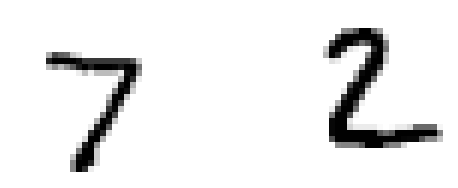

In [27]:
for i, image in enumerate([x_test[0], x_test[1]]):
    plt.subplot(2, 2, i + 1)
    plt.axis("off")
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")

Build scoring dictionary consisting of two digits and send it to deployed model to get predictions.

In [28]:
scoring_payload = {
    client.deployments.ScoringMetaNames.INPUT_DATA: [
        {"values": [image_1.tolist(), image_2.tolist()]}
    ]
}
scores = client.deployments.score(deployment_id, meta_props=scoring_payload)
print("Scoring result:\n" + json.dumps(scores, indent=2))

Scoring result:
{
  "predictions": [
    {
      "id": "classes",
      "values": [
        7,
        2
      ]
    }
  ]
}


#### List deployments

In [29]:
client.deployments.list()

,ID,NAME,STATE,CREATED,ARTIFACT_TYPE,SPEC_STATE,SPEC_REPLACEMENT
0,019e72b7-0471-7481-9386-989a90920919,TF Mnist deployment,ready,2026-05-29T07:50:56.899Z,model,supported,


<a id="6.-Cleanup"></a>
## 6. Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watsonx-ai-samples/blob/master/cpd5.4/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="7.-Summary-and-next-steps"></a>
## 7. Summary and next steps

You successfully completed this notebook! You learned how to use `ibm-watsonx-ai` to train and score TensorFlow models.  

Check out our _<a href="https://ibm.github.io/watsonx-ai-python-sdk/samples.html" target="_blank" rel="noopener no referrer">Online Documentation</a>_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors and Maintainers

**Jan Sołtysik (Former)**, Software Engineer at IBM watsonx.ai

**Rafał Chrzanowski**, Software Engineer at IBM watsonx.ai

**Karol Zmorski**, Software Engineer at IBM watsonx.ai

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.